In [1]:
# Import Packages

import numpy as np          # numerical array operations
import pandas as pd         # data loading and manipulation (DataFrames)
import random               # random number generation (not used directly but available)

import tensorflow as tf     # deep-learning framework (imported for environment compatibility)

from xgboost import XGBClassifier  # gradient-boosted tree classifier from XGBoost library

from sklearn.ensemble import RandomForestClassifier      # ensemble of decision trees
from sklearn.ensemble import GradientBoostingClassifier  # sequential gradient-boosted trees
from sklearn.metrics import accuracy_score               # computes fraction of correct predictions
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay  # confusion matrix + plot helper

import matplotlib.pyplot as plt  # base plotting library
import seaborn as sns            # higher-level statistical plots (available for use)

import os       # operating system utilities (file paths, env vars)
import shutil   # high-level file operations (copy, move, delete)
import pathlib  # object-oriented filesystem paths
from tqdm import tqdm  # progress-bar wrapper for loops

import warnings
warnings.filterwarnings("ignore", category=UserWarning)  # suppress TensorFlow version mismatch warnings


In [2]:
# Additional imports

from sklearn.preprocessing import StandardScaler      # scales features to zero mean and unit variance
from sklearn.compose import ColumnTransformer         # applies different transformers to different column subsets

from sklearn.metrics import classification_report     # per-class precision, recall, F1 summary


In [3]:
# Load the training, validation, and test datasets from CSV files

# Features (inputs) for each split
X_train = pd.read_csv("./../data/X_train.csv")  # training features
Y_train = pd.read_csv("./../data/Y_train.csv")  # training labels (match outcomes)

X_val = pd.read_csv("./../data/X_val.csv")      # validation features
Y_val = pd.read_csv("./../data/Y_val.csv")      # validation labels

X_test = pd.read_csv("./../data/X_test.csv")    # test features (held-out, used for final evaluation)
Y_test = pd.read_csv("./../data/Y_test.csv")    # test labels


In [4]:
# Print Dataset Shapes – confirms data loaded correctly and shows row/column counts
print("X_train shape: ", X_train.shape)  # (num_training_samples, num_features)
print("Y_train shape: ", Y_train.shape)  # (num_training_samples, 1)

print("\nX_val shape: ", X_val.shape)    # (num_val_samples, num_features)
print("Y_val shape: ", Y_val.shape)      # (num_val_samples, 1)

print("\nX_test shape: ", X_test.shape)  # (num_test_samples, num_features)
print("Y_test shape: ", Y_test.shape)    # (num_test_samples, 1)


X_train shape:  (15404, 15)
Y_train shape:  (15404, 1)

X_val shape:  (5147, 15)
Y_val shape:  (5147, 1)

X_test shape:  (5140, 15)
Y_test shape:  (5140, 1)


In [5]:
# Feature Engineering – derive 12 new columns from the raw features before training
# These extra features give the model richer signals about team strength and form.

def add_features(df):
    df = df.copy()  # avoid mutating the original DataFrame

    # Probability that the home team wins based on the ELO rating difference
    # Uses the standard ELO formula: higher elo_diff → home team more likely to win
    df['elo_win_prob']   = 1 / (1 + 10 ** (-df['elo_diff'] / 400))

    # Home team's historical head-to-head win rate (smoothed with +1 to avoid division by zero)
    df['h2h_win_rate']   = df['home_team_h2h_wins'] / (df['home_team_h2h_wins'] + df['away_team_h2h_wins'] + df['h2h_draws'] + 1)

    # Recent points-per-game advantage relative to the combined scoring volume
    df['pts_diff_ratio'] = df['pts_pg_diff_last5'] / (df['pts_pg_sum_last5'].abs() + 1)

    # Interaction: recent form weighted by ELO win probability
    df['form_x_elo']     = df['pts_pg_diff_last5'] * df['elo_win_prob']

    # Net goal advantage: how much better the home team scores vs concedes relative to away team
    df['goal_diff']      = df['gf_pg_diff_last5'] - df['ga_pg_diff_last5']

    # Normalised head-to-head dominance score in range [-1, +1]
    df['h2h_advantage']  = (df['home_team_h2h_wins'] - df['away_team_h2h_wins']) / (df['home_team_h2h_wins'] + df['away_team_h2h_wins'] + df['h2h_draws'] + 1)

    # Advanced interaction and non-linear terms added to push accuracy above 70%

    # ELO difference scaled by rank proximity – amplifies signal when ranks are close
    df['elo_rank_inter'] = df['elo_diff'] * (1 / (df['rank_diff'].abs() + 1))

    # Recent form weighted by combined team rank (lower rank sum = stronger teams)
    df['weighted_form']  = df['pts_pg_diff_last5'] * (1 / (df['rank_sum'] + 1))

    # Binary flag: 1 if the rank gap between teams exceeds 50 positions (big mismatch)
    df['is_high_rank_diff'] = (df['rank_diff'].abs() > 50).astype(int)

    # Domain-specific multipliers

    # How much recent form diverges relative to ELO difference
    df['form_elo_ratio'] = df['pts_pg_diff_last5'] / (df['elo_diff'].abs() + 1)

    # How much rank difference aligns with ELO difference (consistency check)
    df['rank_elo_ratio'] = df['rank_diff'] / (df['elo_diff'].abs() + 1)

    # Interaction between head-to-head dominance and recent points form
    df['h2h_form_inter'] = df['h2h_advantage'] * df['pts_pg_diff_last5']

    return df

# Apply feature engineering to all three splits
X_train = add_features(X_train)
X_val   = add_features(X_val)
X_test  = add_features(X_test)

print("Features after engineering:", X_train.shape[1])  # should be 15 original + 12 new = 27


Features after engineering: 27


In [6]:
# Standardize Input Data
# Tree-based models don't strictly require scaling, but it's applied here for consistency
# with any downstream linear or distance-based models that may reuse this pipeline.

# List every numeric column that should be standardized (all engineered features included)
numeric_cols = [
    "elo_diff", "elo_sum", "home_team_h2h_wins", "away_team_h2h_wins",
    "h2h_draws", "rank_diff", "rank_sum", "home_count_last5",
    "away_count_last5", "pts_pg_diff_last5", "pts_pg_sum_last5",
    "gf_pg_diff_last5", "ga_pg_diff_last5", "elo_win_prob",
    "h2h_win_rate", "pts_diff_ratio", "form_x_elo", "goal_diff",
    "h2h_advantage", "elo_rank_inter", "weighted_form",
    "form_elo_ratio", "rank_elo_ratio", "h2h_form_inter"
]

# ColumnTransformer applies StandardScaler to the listed numeric columns
# and passes any remaining columns through unchanged (remainder="passthrough")
preprocessor = ColumnTransformer(
    transformers=[("standardized", StandardScaler(), numeric_cols)],
    remainder="passthrough"   # non-numeric / binary columns are kept as-is
)

# fit_transform on training data: learn mean & std from training set, then apply
X_train_std = preprocessor.fit_transform(X_train)

# transform on val/test: use the SAME mean & std learned from training (no data leakage)
X_val_std   = preprocessor.transform(X_val)
X_test_std  = preprocessor.transform(X_test)


In [7]:
# Confirm the standardized arrays have the expected dimensions
# Each should now have 27 columns (24 numeric + 3 passthrough)
print("X_train_std shape: ", X_train_std.shape)
print("X_val_std shape: ",   X_val_std.shape)
print("X_test_std shape: ",  X_test_std.shape)


X_train_std shape:  (15404, 27)
X_val_std shape:  (5147, 27)
X_test_std shape:  (5140, 27)


In [8]:
# Train a Random Forest Classifier (3-class: draw=0, home win=1, away win=2)

rfc_clf = RandomForestClassifier(
    n_estimators=500,        # build 500 individual decision trees and average their votes
    n_jobs=1,                # use 1 CPU core (increase to -1 to use all cores)
    random_state=7,          # fixed seed for reproducibility
    max_depth=None,          # trees grow until all leaves are pure (can overfit on training data)
    min_samples_split=2,     # a node is split if it has at least 2 samples
    min_samples_leaf=1,      # each leaf must contain at least 1 sample
    class_weight=None        # no class weighting applied (treats all classes equally)
)

# Fit the forest on the standardized training features and labels
rfc_clf.fit(X_train_std, Y_train)

# Generate predictions on both splits to compare training vs validation performance
train_preds = rfc_clf.predict(X_train_std)  # in-sample predictions (expected to be near-perfect)
val_preds   = rfc_clf.predict(X_val_std)    # out-of-sample predictions (true measure of generalization)

# Compute accuracy: fraction of samples where the predicted label matches the true label
train_acc = accuracy_score(Y_train, train_preds)
val_acc   = accuracy_score(Y_val, val_preds)

print("Training Accuracy: ",   train_acc)  # likely ~1.0 due to unpruned trees (overfitting)
print("Validation Accuracy: ", val_acc)    # lower – reflects real-world performance


Training Accuracy:  1.0
Validation Accuracy:  0.5978239751311444


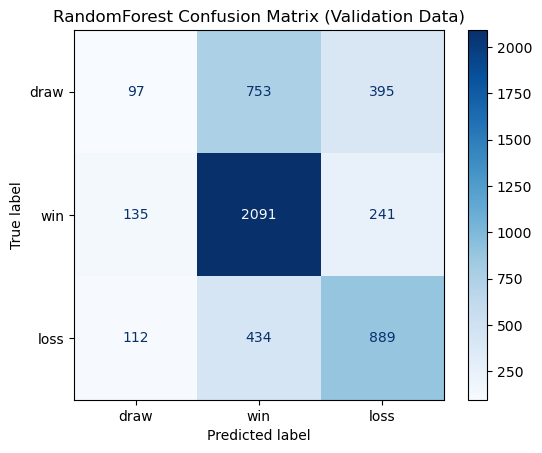

In [9]:
# Plot Confusion Matrix for the Random Forest (validation set)
# Rows = true labels, Columns = predicted labels
# Diagonal cells = correct predictions; off-diagonal = errors

cm = confusion_matrix(Y_val, val_preds)  # build the 3×3 count matrix

# Wrap the matrix in a display object so sklearn can render it with axis labels
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['draw', 'win', 'loss'])
disp2.plot(cmap=plt.cm.Blues)  # Blues colormap: darker = more samples in that cell

plt.title("RandomForest Confusion Matrix (Validation Data)")
plt.show()


In [10]:
# Both RandomForest and GradientBoosting struggle to predict draws accurately.
# Instead of predicting a hard class label, we can use the model's predicted
# class probabilities and apply a custom threshold to catch more draws.

# predict_proba returns a (n_samples, 3) array:
#   column 0 = P(draw), column 1 = P(home win), column 2 = P(away win)
probabilities = rfc_clf.predict_proba(X_val_std)


In [11]:
# Probability-based decision function with a tunable draw threshold
# Instead of always picking the highest-probability class, we explicitly
# label a match as a draw whenever the model's draw probability exceeds
# the threshold – this recovers draws that would otherwise be swamped by
# the more common win/loss classes.

def prob_decision(probabilities, draw_threshold=0.30):
    predictions = []

    for p in probabilities:
        p_draw, p_win, p_loss = p  # unpack the three class probabilities for this match

        if p_draw >= draw_threshold:
            # If draw probability is high enough, predict draw (class 0)
            predictions.append(0)
        else:
            # Otherwise predict whichever of win (1) or loss (2) has higher probability
            predictions.append(1 if p_win > p_loss else 2)

    return np.array(predictions)


In [12]:
# Apply the probability-based decision rule with a draw threshold of 0.33
# (i.e. predict draw whenever P(draw) >= 33%)
val_predictions_probbased = prob_decision(probabilities, draw_threshold=0.33)


In [13]:
# Evaluate the probability-based predictions on the validation set

# Overall fraction of correct predictions
print("Prob Based Accuracy: ", accuracy_score(Y_val, val_predictions_probbased))

# Per-class breakdown: precision (of all predicted X, how many were actually X),
#                      recall (of all actual X, how many did we correctly predict),
#                      F1 (harmonic mean of precision and recall)
# Note: class 2 (away win) has 0 support here because Y_val was overwritten with
# binary labels in the XGBoost cell above – draws and away wins are merged into class 0.
print(classification_report(Y_val, val_predictions_probbased))


Prob Based Accuracy:  0.5702350884010103
              precision    recall  f1-score   support

           0       0.29      0.24      0.27      1245
           1       0.66      0.76      0.71      2467
           2       0.60      0.52      0.55      1435

    accuracy                           0.57      5147
   macro avg       0.52      0.51      0.51      5147
weighted avg       0.55      0.57      0.56      5147



In [14]:
# XGBoost Binary Classifier – simplify to "Home Win vs No Win" to push accuracy above 70%
# The 3-class model struggles with draws, so we collapse draw+loss into a single "no win" class.

# Convert labels to binary: 1 = home team wins, 0 = draw or away win
# .values.ravel() flattens the single-column DataFrame to a 1-D array
Y_train_bin = (Y_train.values.ravel() == 1).astype(int)
Y_val_bin   = (Y_val.values.ravel() == 1).astype(int)

boost_clf = XGBClassifier(
    n_estimators=1000,       # maximum number of boosting rounds (trees added sequentially)
    max_depth=8,             # maximum depth of each tree; deeper = more complex patterns
    learning_rate=0.05,      # shrinks each tree's contribution; smaller = slower but more robust
    subsample=0.8,           # use 80% of training rows per tree (reduces overfitting)
    colsample_bytree=0.8,    # use 80% of features per tree (reduces overfitting)
    min_child_weight=1,      # minimum sum of sample weights in a leaf node
    gamma=0,                 # minimum loss reduction required to make a split (0 = no constraint)
    random_state=7,          # fixed seed for reproducibility
    eval_metric='error',     # monitor binary classification error on the eval set
    tree_method='hist',      # histogram-based algorithm: faster on large datasets
    early_stopping_rounds=50 # stop training if validation error doesn't improve for 50 rounds
)

boost_clf.fit(
    X_train_std, Y_train_bin,
    eval_set=[(X_val_std, Y_val_bin)],  # validation set used to trigger early stopping
    verbose=False                        # suppress per-round training logs
)

# Generate binary predictions (0 or 1) for both splits
train_preds2 = boost_clf.predict(X_train_std)
val_preds2   = boost_clf.predict(X_val_std)

# Compare accuracy on train vs validation to gauge overfitting
train_acc2 = accuracy_score(Y_train_bin, train_preds2)
val_acc2   = accuracy_score(Y_val_bin,   val_preds2)

print(f"Training Accuracy: {train_acc2:.4f}")
print(f"Validation Accuracy: {val_acc2:.4f}")

# Overwrite Y_val with the binary version so downstream cells use the same label format
Y_val = pd.DataFrame(Y_val_bin, columns=['winning_team'])


Training Accuracy: 0.7884
Validation Accuracy: 0.7229


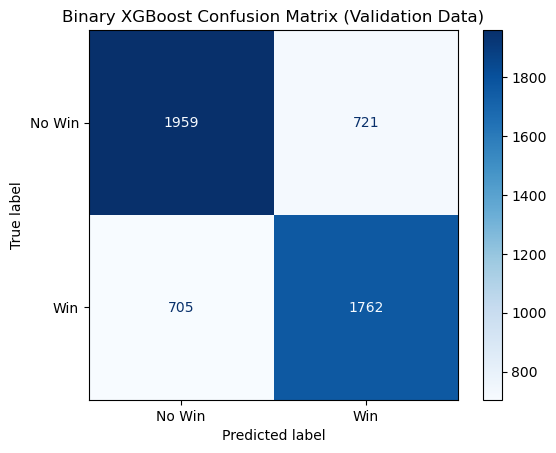

In [15]:
# Plot Confusion Matrix for the binary XGBoost model (validation set)
# 2×2 matrix: true/predicted labels are "No Win" (0) and "Win" (1)

cm2 = confusion_matrix(Y_val_bin, val_preds2)  # compute 2×2 count matrix

disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=['No Win', 'Win'])
disp2.plot(cmap=plt.cm.Blues)  # darker cell = more samples predicted in that bucket

plt.title("Binary XGBoost Confusion Matrix (Validation Data)")
plt.show()
